In [31]:
from nltk import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.tag import hmm
from nltk.chunk import RegexpParser
from nltk import ne_chunk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
import nltk
from nltk.grammar import CFG
from nltk.parse.generate import generate
import spacy
from spacy import displacy
import requests
from bs4 import BeautifulSoup
from nltk.corpus import treebank
from collections import Counter
import matplotlib.pyplot as plt
import requests
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import re
import requests
from bs4 import BeautifulSoup
import re
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

<h3> Zadanie1: Podziel wyjściowy zbiór sentencji $treebank.tagged\_sents()$ na dwa zbiory: pierwsze 3000 sentencje zapisz pod zmienną  $trained$, natomiast pozostałe sentencje zapisz pod zmienną $tested$. Zbuduj model tylko w oparciu o $trained$. Następnie wykonaj ewaluacje modelu zarówno na  $trained$  jak i  $tested$. Zastanów się z czego mogą wynikać rozbieżności.

In [14]:
treebank.readme().replace('\n', ' ')
sentences = treebank.tagged_sents()

trained = sentences[:3000]
tested = sentences[3000:]

trainer = hmm.HiddenMarkovModelTrainer() 
tagger = trainer.train_supervised(trained)

acc_trained = tagger.accuracy(trained)
acc_tested = tagger.accuracy(tested)

print(f"Dokładność na zbiorze treningowym: {acc_trained:.4f}")
print(f"Dokładność na zbiorze testowym: {acc_tested:.4f}")

Dokładność na zbiorze treningowym: 0.9816
Dokładność na zbiorze testowym: 0.3684


<h4> Zbiór treningowy otrzymał wynik niemal 1, z kolei zbiór testowy ok. 0.37 -> spowodowane to może być tym, że w zbiorze testowym znalały się słowa, których nie było w zbiorze treningowym. Zbiór treningowy mógł nauczyć się pewnych odmian słowa, a gdy w zbiorze testowym wystapi (np. w innym kontekście), model go nie rozpozna bo umie inna wersje.

<h3> Zadanie2: Zinterpretuj poniższy chunk.

In [17]:
text = "The Very Large Telescope (VLT) of the European Southern Observatory (ESO), an array of four individual telescopes in the Atacama desert, has given us a huge amount of new data about the universe. Researchers have now used it to find a group of six galaxies around a supermassive black hole, from when the Universe was just 0.9 billion years old - it's estimated to be 13.8 billion years old now. Black holes are thought to sit at the center of galaxies including the Milky Way. "
sentences = sent_tokenize(text.lower())
tokens_sen1 = word_tokenize(sentences[0])
tags = pos_tag(tokens_sen1)

In [ ]:
grammar = "chunk: {<NN.?>*<VBD.?>*<JJ.?>*<CC>?}" #co oznacza wyrazenie regularne zapisane w {}?
chunker = RegexpParser(grammar) 
result = chunker.parse(tags) #tags zdefiniowane bylo wyzej
result.draw()

In [ ]:
"""
Chunk mówi: 
    - <NN.?>* - jakakolwiek ilość rzeczowników (od 0) plus odmian NN np. NNS, 
    - <VBD.?>* - dowolna liczba czasowników w czasie przeszłym plus odmiany
    - <JJ.?>*: Dowolna liczba przymiotników plus odmiany
    - <CC>?: spójnik, który może być ale nie musi

"""

<h3> Zadanie3: Znajdz wszystkie byty (entity) w tekście poniżej.

In [2]:
txt = "Google, LLC is an American multinational technology company that specializes in Internet-related services and products, which include online advertising technologies, a search engine, cloud computing, software, and hardware. It is considered one of the Big Five technology companies in the U.S. information technology industry, alongside Amazon, Facebook, Apple, and Microsoft."

In [8]:
txt_tokenized = word_tokenize(txt)
tags_txt = pos_tag(txt_tokenized)

#Przeszukiwanie
namedEnt = ne_chunk(tags_txt, binary = True) 
print(namedEnt)

(S
  (NE Google/NNP)
  ,/,
  (NE LLC/NNP)
  is/VBZ
  an/DT
  (NE American/JJ)
  multinational/NN
  technology/NN
  company/NN
  that/WDT
  specializes/VBZ
  in/IN
  Internet-related/NNP
  services/NNS
  and/CC
  products/NNS
  ,/,
  which/WDT
  include/VBP
  online/JJ
  advertising/NN
  technologies/NNS
  ,/,
  a/DT
  search/NN
  engine/NN
  ,/,
  cloud/NN
  computing/NN
  ,/,
  software/NN
  ,/,
  and/CC
  hardware/NN
  ./.
  It/PRP
  is/VBZ
  considered/VBN
  one/CD
  of/IN
  the/DT
  Big/NNP
  Five/NNP
  technology/NN
  companies/NNS
  in/IN
  the/DT
  (NE U.S./NNP)
  information/NN
  technology/NN
  industry/NN
  ,/,
  alongside/RB
  (NE Amazon/NNP)
  ,/,
  (NE Facebook/NNP)
  ,/,
  (NE Apple/NNP)
  ,/,
  and/CC
  (NE Microsoft/NNP)
  ./.)


<h3> Zadanie4: Znajdź wszystkie hiponimy i hiperonimy dla słowa $dog$. Zacznij od wyszukania synsetów dla tego słowa, wybierz pierwszy z nich.

In [22]:
piesek = wn.synset("dog.n.01")

In [27]:
rozne_pieski = piesek.hyponyms()
print(rozne_pieski[0])
print("       ")
print([lemma.name() for synset in rozne_pieski for lemma in synset.lemmas()])

Synset('basenji.n.01')
       
['basenji', 'puppy', 'spitz', 'Great_Pyrenees', 'working_dog', 'hunting_dog', 'poodle', 'poodle_dog', 'Mexican_hairless', 'Leonberg', 'Newfoundland', 'Newfoundland_dog', 'pug', 'pug-dog', 'corgi', 'Welsh_corgi', 'dalmatian', 'coach_dog', 'carriage_dog', 'cur', 'mongrel', 'mutt', 'lapdog', 'pooch', 'doggie', 'doggy', 'barker', 'bow-wow', 'griffon', 'Brussels_griffon', 'Belgian_griffon', 'toy_dog', 'toy']


In [24]:
pieskowe_hiperonimy = piesek.hypernyms()
print([lemma.name() for synset in pieskowe_hiperonimy for lemma in synset.lemmas()])

['domestic_animal', 'domesticated_animal', 'canine', 'canid']


<h3> Zadanie5: Znajdź synonimy i antonimy słowa $happy$.

In [39]:
synonimy = []
for syn in wn.synsets('happy'):
    for lemma in syn.lemmas(): 
        synonimy.append(lemma.name())

antonimy = []

for syn in wn.synsets("happy"):
        for l in syn.lemmas():
            if l.antonyms():
                antonimy.append(l.antonyms()[0].name())
print(synonimy)
print(antonimy)

['happy', 'felicitous', 'happy', 'glad', 'happy', 'happy', 'well-chosen']
['unhappy']


<h3> Zadanie6: Porównaj podobieństwo słów dog, cat i fish.

In [40]:
dog = wn.synsets('dog')[0]
cat = wn.synsets('cat')[0]
fish = wn.synsets('fish')[0]

dog.wup_similarity(cat), cat.wup_similarity(fish), dog.wup_similarity(fish)

(0.8571428571428571, 0.72, 0.75)

<h3> Zadanie7: Z użyciem bibliotek spacy/nltk przeanalizuj teksty: Ogniem i mieczem oraz Tajemnicza wyspa. 
    
- Jakie top 10 słów niebędących stopwordsami występuje w obu lekturach najczęściej (podaj częstość, można zwizualizować)?
    
- Jakie top 10 POStagów występuje w obu lekturach najczęściej (podaj częstości)?

In [3]:
nlp = spacy.load("pl_core_news_lg")

def lektury(url, tytul):
    response = requests.get(url)
    response.encoding = 'utf-8' 
    tekst = response.text

    nlp.max_length = 2000000
    doc = nlp(tekst) 


    slowa = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    

    tagi = [token.pos_ for token in doc if not token.is_space and not token.is_punct]

    return Counter(slowa).most_common(10), Counter(tagi).most_common(10)


url_ogniem = "https://clarin-pl.eu/dspace/bitstream/handle/11321/110/sienkiewicz_ogniem_1884.txt?sequence=1&isAllowed=y"
url_wyspa = "https://clarin-pl.eu/dspace/bitstream/handle/11321/465/TajemniczaWyspa.txt?sequence=1&isAllowed=y"


top_slowa_ogniem, top_pos_ogniem = lektury(url_ogniem, "Ogniem i mieczem")
top_slowa_wyspa, top_pos_wyspa = lektury(url_wyspa, "Tajemnicza wyspa")

# Wyświetlenie wyników
print("\nOGNIEM I MIECZEM")
print("Top 10 słów:", top_slowa_ogniem)
print("Top 10 POS:", top_pos_ogniem)

print("\nTAJEMNICZA WYSPA")
print("Top 10 słów:", top_slowa_wyspa)
print("Top 10 POS:", top_pos_wyspa)


OGNIEM I MIECZEM
Top 10 słów: [('rzec', 881), ('zagłoba', 784), ('skrzetuski', 762), ('książę', 677), ('mówić', 605), ('oko', 592), ('ręka', 591), ('chmielnicki', 562), ('bóg', 527), ('móc', 526)]
Top 10 POS: [('NOUN', 54728), ('VERB', 41585), ('ADP', 25990), ('PRON', 21554), ('ADJ', 20057), ('CCONJ', 14419), ('PROPN', 12766), ('PART', 12570), ('ADV', 12156), ('SCONJ', 9171)]

TAJEMNICZA WYSPA
Top 10 słów: [('pencroff', 128), ('harbert', 114), ('marynarz', 105), ('nab', 74), ('cyrus', 73), ('swój', 72), ('morze', 70), ('brzeg', 69), ('balon', 67), ('smith', 62)]
Top 10 POS: [('NOUN', 5156), ('VERB', 3056), ('ADP', 2297), ('ADJ', 2047), ('PRON', 1374), ('ADV', 1088), ('PART', 1018), ('CCONJ', 888), ('PROPN', 868), ('DET', 857)]


<h3> Zadanie8: Wejdź na dowolną listę przebojów (np. https://www.rmfmaxx.pl/hopbec) a następnie pobierz teksty piosenek z kolejnych pozycji. 

- Zamień wszystkie wyrazy na rozpoczynające się z małej litery. 
- Dokonaj tokenizacji ze wzglęu na słowa. 
- Wyznacz miarę Herdana dla każdego z tekstów.
- Narysuj zależność pomiędzy zajmowanym na liście miejscem a miarą Herdana. Wyznacz współczynnik korelacji. Zinterpretuj jego wartość.

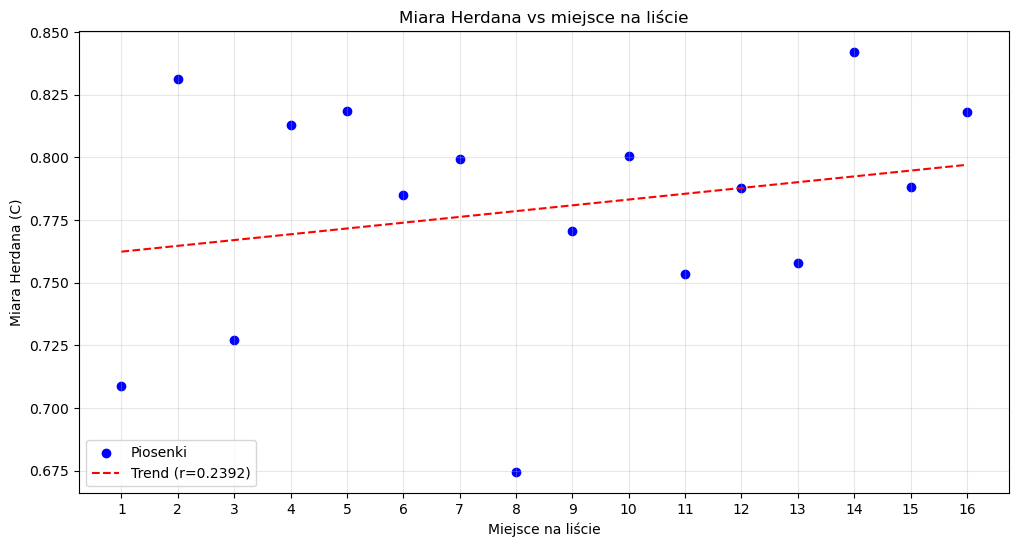

In [67]:
#Lista wzięta z https://www.rmfmaxx.pl/hopbec

file_path = 'teksty_piosenek.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    raw_content = f.read()

# Podział na ranking
songs_blocks = re.split(r'\n(?=\d+[\.\s])', '\n' + raw_content)
processed_data = []

for block in songs_blocks:
    block = block.strip()
    
    lines = block.split('\n')
    header = lines[0] # Linia z numerem, wykonawcą i tytułem
    lyrics = " ".join(lines[1:]) # Tekst
    
    match = re.match(r'^(\d+)', header)
    if match:
        song_index = int(match.group(1))
        processed_data.append({
            'index': song_index,
            'title': header,
            'text': lyrics
        })

# Miara Herdana
results = []

for song in processed_data:
    # Zamiana na małe litery
    text_lower = song['text'].lower()
    
    # Tokenizacja 
    tokens = word_tokenize(text_lower)
    
    N = len(tokens)           # Liczba wszystkich słów
    V = len(set(tokens))      # Liczba unikalnych słów
    
  
    herdan = math.log10(V) / math.log10(N)

        
    results.append((song['index'], herdan, song['title']))

# Sortowanie wyników według kolejności z pliku
results.sort(key=lambda x: x[0])
indices, herdan_values, titles = zip(*results)

# Analiza 
corr_coef, _ = pearsonr(indices, herdan_values)

plt.figure(figsize=(12, 6))
plt.scatter(indices, herdan_values, color='blue', label='Piosenki')

z = np.polyfit(indices, herdan_values, 1)
p = np.poly1d(z)
plt.plot(indices, p(indices), "r--", label=f"Trend (r={corr_coef:.4f})")

plt.title('Miara Herdana vs miejsce na liście')
plt.xlabel('Miejsce na liście')
plt.ylabel('Miara Herdana (C)')
plt.xticks(indices)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

                       

In [68]:
print(f"Współczynnik korelacji Persona: {corr_coef:.4f}")

Współczynnik korelacji Persona: 0.2392


<h4> Współczynnik korelacji Persona wynosi ok. 0.24 -> jest to wynik dość niski (im bliżej 1 tym silniejsza korelacja). Wskazuje to, że jest delikatna zależność między pozycja na liście hitów a tym, jak złożony i różnorodny tekst jest w piosenkach. 

Komentarz: Próbowałam pobrać artystów i tytuły, ale problem pojawiał się z tekstowo- niektóre piosenki były podzielone i podpisane na wersy, chórki, refreny co uniemożliwiało programowi wyciagnięcie tekstu. Dlatego autorzy, tytuły i piosenki zostały zapisane do jednego pliku. 